# Reading from an explicit zoom level

Most whole-slide formats store an image as a pyramid: the full-resolution raster plus a series of progressively smaller copies. `read_block` hides that pyramid. You give it a rectangle in full-resolution scene coordinates together with the output size you want, and SlideIO picks whichever level serves that request best.

That is convenient, and for most work it is the right method. But a tiled viewer already knows which level it wants — it addresses image data as `(level, tile_column, tile_row)`. Expressing that in scene coordinates means converting down, in integers, and letting the library convert back. Pyramid downsamples are frequently not exact powers of two, so the round trip rounds twice, and the ratio that survives it is what the level search sees. Two consequences show up in practice: levels can end up a pixel or two out of alignment with each other, and a request can be served from a finer level than intended and then resized.

`read_block_from_level` removes the round trip. You name the level, and the rectangle you pass is interpreted **in that level's own pixel coordinates**. This notebook covers:

1. inspecting a pyramid — `num_zoom_levels` and `get_zoom_level_info`
2. reading a region from a named level
3. walking a level tile by tile, the way a viewer or a tile cache would
4. three things that will bite you if you assume rather than ask

The level API requires **slideio 2.9.0 or newer**.

In [1]:
import slideio
from utils import get_driver_test_images, display_driver_test_image_info, \
                    show_image, show_images
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
slideio.get_version()

'2.9.0'

# Test images
For the demonstrations below we use some of the test images shipped with this repository. Information about the images and the drivers needed to read them is stored in *images.json*; the helper `get_driver_test_images` loads the entries for one driver.

The main example is an Olympus VSI slide, which carries a six level pyramid with a regular 512x512 tile grid.

In [3]:
images = get_driver_test_images('VSI')
display_driver_test_image_info(images, 'VSI')

Image Path,Driver
./images/vsi-ets-test-jpg2k.vsi,VSI
./images/Image_Mouse13_PB_H7.vsi,VSI
./images/KXXM5V73XBHBK5ZVPMJT483PBR.vsi,VSI


# 1. Inspecting the pyramid

A scene reports how many levels it has through `num_zoom_levels`, and describes each one through `get_zoom_level_info(index)`. Level 0 is always the full-resolution level.

In [4]:
slide = slideio.open_slide('./images/Image_Mouse13_PB_H7.vsi', 'VSI')
scene = slide.get_scene(0)

print('scene name          :', scene.name)
print('scene rect          :', scene.rect)
print('channels            :', scene.num_channels)
print('magnification       :', scene.magnification)
print('number of levels    :', scene.num_zoom_levels)

scene name          : 40x
scene rect          : (0, 0, 12758, 12757)
channels            : 3
magnification       : 40.0
number of levels    : 6


In [5]:
rows = []
for index in range(scene.num_zoom_levels):
    info = scene.get_zoom_level_info(index)
    rows.append({
        'level': info.level,
        'size': f'{info.size.width} x {info.size.height}',
        'scale': info.scale,
        'magnification': info.magnification,
        'tile size': f'{info.tile_size.width} x {info.tile_size.height}',
        'tiles': info.tile_count,
    })

pd.DataFrame(rows).set_index('level')

,size,scale,magnification,tile size,tiles
level,,,,,
0,12758 x 12757,1.000000,40.000000,512 x 512,625
1,6379 x 6378,0.500000,20.000000,512 x 512,169
2,3189 x 3189,0.249961,9.998432,512 x 512,49
3,1594 x 1594,0.124941,4.997649,512 x 512,16
4,797 x 797,0.062471,2.498824,512 x 512,4
5,398 x 398,0.031196,1.247844,512 x 512,1


Two details in that table are worth pausing on, because they are the reason this API exists.

**`scale` is measured, not assumed.** Level 1 comes out at exactly 0.5, but level 2 is 0.249961 rather than 0.25. The base width is 12758 and halving it repeatedly truncates, so the stored levels are not exact powers of two. Any arithmetic that assumes `1 / 2**level` will drift from what the file actually contains — which is precisely the drift a scene-coordinate round trip introduces.

**`tiles` is the tile count of that level**, and `tile size` the size of one tile. Together with `get_tile_rect` they let you enumerate a level's tile grid without computing it yourself; section 3 uses them.

# 2. Reading from a named level

`read_block_from_level(level, rect, size, channel_indices, slices, frames)` mirrors `read_block`, with two differences that matter:

- `rect` is in the coordinate system of `level`, not of the scene. A width or height of `0` extends to the edge of **that level**.
- `size=(0, 0)` — the default — returns the level's native pixels with no resampling at all.

Called with only a level, it returns that whole level.

level 5 is 398 x 398; the returned array is (398, 398, 3)


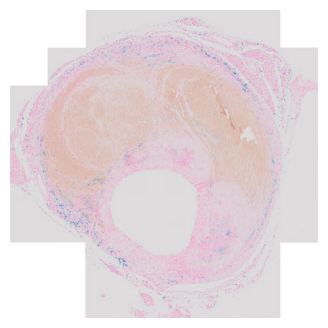

In [6]:
coarsest = scene.num_zoom_levels - 1
info = scene.get_zoom_level_info(coarsest)

thumbnail = scene.read_block_from_level(coarsest)

print(f'level {coarsest} is {info.size.width} x {info.size.height}; '
      f'the returned array is {thumbnail.shape}')
show_image(thumbnail, 400)

A sub-rectangle works the same way. The rectangle below is at (1024, 1024) **of level 2** — it is not a scene coordinate, and no conversion is applied to it.

Passing `size` resamples the block, but the data still comes from the level you named. That is the guarantee `read_block` cannot give you: here the 128x128 result is a downsample of level 2, not a read of whichever level happens to be 128 pixels wide.

native   : (512, 512, 3)
resampled: (128, 128, 3)


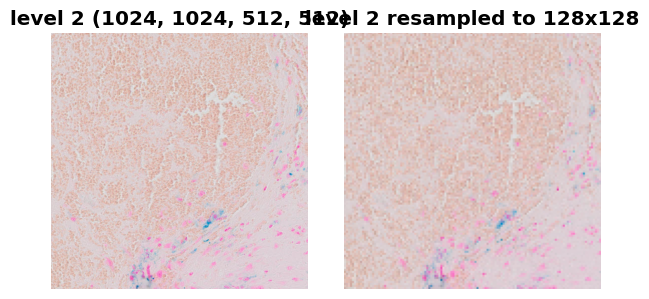

In [7]:
level = 2
rect = (1024, 1024, 512, 512)

native = scene.read_block_from_level(level, rect=rect)
resampled = scene.read_block_from_level(level, rect=rect, size=(128, 128))

print('native   :', native.shape)
print('resampled:', resampled.shape)

show_images([native, resampled],
            [f'level {level} {rect}', f'level {level} resampled to 128x128'],
            300, columns=2)

# 3. Walking a level tile by tile

This is the use case the API was added for. A viewer or a tile cache wants each stored tile of a level, once, at native resolution.

`LevelInfo` gives you the grid directly: `tile_count` and `get_tile_rect(index)`, which returns a rectangle already in level coordinates. There is no need to compute the grid from the level size and tile size yourself.

The cell below reads every tile of level 3 and stitches them back together, then asserts that the mosaic is identical to a single read of the whole level. The assertion is the point — it is what makes this a demonstration rather than two pictures that merely look alike.

level 3: 1594 x 1594, 16 tiles of 512 x 512
the stitched tiles are identical to a single whole-level read


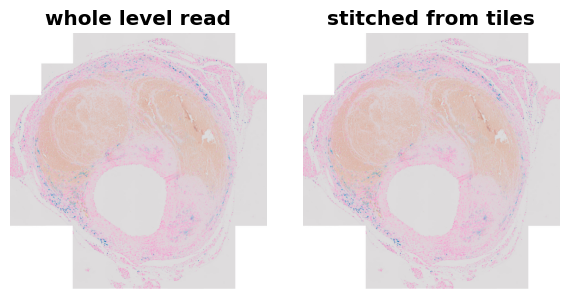

In [8]:
level = 3
info = scene.get_zoom_level_info(level)
level_width, level_height = info.size.width, info.size.height

print(f'level {level}: {level_width} x {level_height}, '
      f'{info.tile_count} tiles of {info.tile_size.width} x {info.tile_size.height}')

reference = scene.read_block_from_level(level)
mosaic = np.zeros_like(reference)

for index in range(info.tile_count):
    r = info.get_tile_rect(index)
    tile = scene.read_block_from_level(level, rect=(r.x, r.y, r.width, r.height))
    # Tiles on the right and bottom edges overhang the level; only the part
    # inside it belongs in the mosaic. Section 4.3 looks at that padding.
    height = min(r.height, level_height - r.y)
    width = min(r.width, level_width - r.x)
    mosaic[r.y:r.y + height, r.x:r.x + width] = tile[:height, :width]

assert np.array_equal(mosaic, reference), 'stitched tiles do not reproduce the level'
print('the stitched tiles are identical to a single whole-level read')

show_images([reference, mosaic], ['whole level read', 'stitched from tiles'],
            300, columns=2)

# 4. Three things to watch out for

Each of these is a property of real files rather than of the API, and each will produce a plausible-looking wrong answer if you assume instead of asking.

## 4.1 `scene.rect` is not always zero based

Level rectangles always start at (0, 0). `scene.rect` does not have to: some formats report the scene's physical position on the slide. The Leica SCN file below has an origin far from zero, while its level 0 is the same *size* with an origin of (0, 0).

So `scene.rect` cannot be passed to `read_block_from_level` as a level rectangle. To read a whole level, either call the method with just a level, or build the rectangle from `get_zoom_level_info(level).size`.

In [9]:
scn = slideio.open_slide('./images/Leica-Fluorescence-1.scn', 'SCN')
scn_scene = scn.get_scene(0)
scn_info = scn_scene.get_zoom_level_info(0)

print('scene.rect          :', scn_scene.rect)
print('level 0 size        :', f'{scn_info.size.width} x {scn_info.size.height}')
print()
print('the scene origin is', scn_scene.rect[:2], 'but level coordinates start at (0, 0)')

scene.rect          : (16306, 40361, 4737, 6338)
level 0 size        : 4737 x 6338

the scene origin is (16306, 40361) but level coordinates start at (0, 0)


## 4.2 `tile size` is not always square, or even close

512x512 and 256x256 are common, so it is tempting to hard-code one. Striped formats do not oblige. The Hamamatsu NDPI file below stores rows in strips, which SlideIO reports as very wide, very short tiles — and consequently a great many of them.

Read the tile size from `LevelInfo`; do not assume it.

In [10]:
ndpi = slideio.open_slide('./images/2017-02-27 15.22.39.ndpi', 'NDPI')
ndpi_scene = ndpi.get_scene(0)

for index in range(ndpi_scene.num_zoom_levels):
    ndpi_info = ndpi_scene.get_zoom_level_info(index)
    print(f'level {index}: size {ndpi_info.size.width:>6} x {ndpi_info.size.height:<6} '
          f'tile {ndpi_info.tile_size.width:>5} x {ndpi_info.tile_size.height:<5} '
          f'tiles {ndpi_info.tile_count}')

level 0: size   7680 x 11008  tile  1920 x 8     tiles 5504
level 1: size   1920 x 2752   tile   480 x 8     tiles 1376
level 2: size    480 x 688    tile   120 x 8     tiles 344


## 4.3 Edge tiles overhang, and come back padded

A level's size is rarely an exact multiple of its tile size, so the tiles in the last row and column extend past the edge of the level. `get_tile_rect` returns them at full tile size anyway, and `read_block_from_level` returns an array of the size you asked for, with the region outside the level filled with the background value — 255 for 8-bit images, 0 otherwise.

That is deliberate, and it is what makes a fixed-size tile cache simple: every tile in the grid has the same shape, so no special case is needed at the edges. Just remember that part of an edge tile is padding rather than image, as the mosaic loop in section 3 did.

level 3 is 1594 x 1594
last tile rect     : (1536, 1536, 512, 512)
returned array     : (512, 512, 3)
real image content : 58 x 58; the remainder is padding


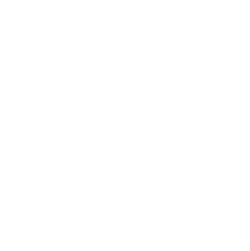

In [11]:
level = 3
info = scene.get_zoom_level_info(level)
last = info.get_tile_rect(info.tile_count - 1)

edge_tile = scene.read_block_from_level(level, rect=(last.x, last.y, last.width, last.height))

real_width = min(last.width, info.size.width - last.x)
real_height = min(last.height, info.size.height - last.y)

print(f'level {level} is {info.size.width} x {info.size.height}')
print(f'last tile rect     : ({last.x}, {last.y}, {last.width}, {last.height})')
print(f'returned array     : {edge_tile.shape}')
print(f'real image content : {real_width} x {real_height}; the remainder is padding')

show_image(edge_tile, 300)

An out-of-range level is an error rather than a clamp, so a bug in level arithmetic surfaces immediately instead of quietly returning the wrong resolution.

In [12]:
try:
    scene.read_block_from_level(scene.num_zoom_levels)
except RuntimeError as error:
    print('RuntimeError:', error)

RuntimeError: D:\conan2\p\b\slide3c8f0d1fff936\b\src\src\slideio\core\cvscene.cpp:213:Invalid level index: 6 Expected range: [0,6)


# Summary

- `num_zoom_levels` and `get_zoom_level_info(index)` describe the pyramid: size, scale, magnification, tile size and tile count per level.
- `read_block_from_level(level, rect, size, ...)` reads from the level you name. `rect` is in that level's coordinates and is never rescaled; `size` resamples within the level and never causes a different one to be read.
- `LevelInfo.tile_count` and `LevelInfo.get_tile_rect(index)` enumerate a level's tile grid, so a viewer does not have to recompute it.
- Ask the file for its geometry. Scale is measured rather than an exact power of two, `scene.rect` need not start at (0, 0), and tile size need not be square.

Use `read_block` when you want a region at a convenient size and do not care which level supplies it. Use `read_block_from_level` when the level is part of what you are asking for.